In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [44]:
df = pd.read_csv("data (1).csv")
df.head(5)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [5]:
df.shape



(4600, 18)

In [6]:
df.isnull().sum()


,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [7]:
df.duplicated().sum()


np.int64(0)

In [41]:
X = df[['sqft_living']]
y = df['price']


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [46]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [47]:
y_pred = lr.predict(X_test)
y_pred


array([ 364098.33163107,  508399.10707922,  759589.34582231,
        561843.83872669,  433576.48277277,  727522.50683383,
        540465.9460677 ,  532449.23632058,  527104.76315584,
        537793.70948533,  783639.47506367,  227814.26593003,
        834411.97012876,  535121.47290296,  398837.40720192,
        756917.10923994,  692783.43126298,  690111.19468061,
        882512.22861148,  954662.61633556,  724850.27025146,
        703472.37759247,  604599.62404466,  511071.3436616 ,
        195747.42694155,  182386.24402969,  674077.77518637,
        818378.55063452,  332031.49264259,  652699.88252738,
       1633410.70825837,  299964.65365411, 1221886.27457289,
        588566.20455042,  273242.28783038,  543138.18265008,
        871823.28228199,  962679.32608268,  294620.18048936,
        585893.96796805,  422887.53644328,  374787.27796056,
        516415.81682634,  462971.08517888,  310653.5999836 ,
        324014.78289547,  487021.21442024,  543138.18265008,
        818378.55063452,

In [48]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)


R2 Score: 0.029065410341410414


In [49]:
from sklearn.metrics import mean_squared_error

print("MSE:", mean_squared_error(y_test, y_pred))


MSE: 990204087727.1417


In [50]:
m = lr.coef_
c = lr.intercept_

print("Slope (m):", m)
print("Intercept (c):", c)


Slope (m): [267.22365824]
Intercept (c): -26048.2093954297


In [51]:
# Predict price for 2000 sqft house
predicted_price = m * 2000 + c
predicted_price


array([508399.10707922])

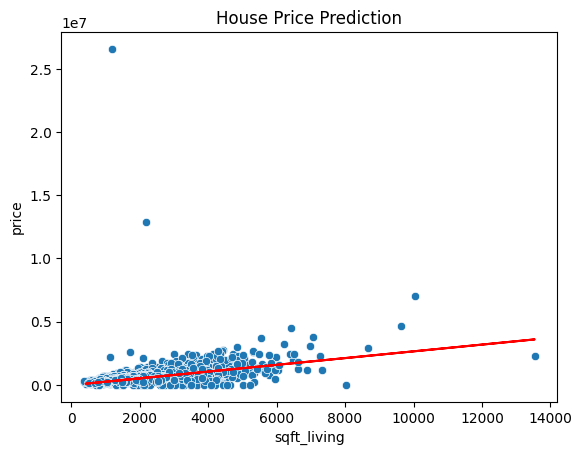

In [53]:
sns.scatterplot(x='sqft_living', y='price', data=df)
plt.plot(X_test, lr.predict(X_test), color='red')
plt.title("House Price Prediction")
plt.show()
